# CRCNS AA5: inspection of the awake zebra-finch repertoire dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/aa5_inspection.ipynb)

This notebook is a **visual tour** of the deepSTRF loader for
**[CRCNS AA5](https://crcns.org/data-sets/aa/aa-5)** (Robotka, Gahr &
Theunissen, 2022; paper: Robotka et al., *Cell Reports* 2023). The data are
chronic extracellular recordings from the auditory pallium of **awake,
freely behaving zebra finches** listening to their whole vocal repertoire:
110 calls over 10 call types, songs, filtered songs and ripples.

It covers:

1. loading the dataset from the slim cache;
2. the stimulus set, with one example per call type;
3. one unit's responses (spectrogram, raster and PSTH);
4. the population onset response, a check that stimuli and spikes line up;
5. unit quality metadata (`spike_snr`, `auditory_z`);
6. the trial-quality bookkeeping (`playback_meta`);
7. simultaneously recorded units, re-aligned trial by trial;
8. filtering.

## Setup

On Google Colab, the cell below installs deepSTRF from source. On a local
install it does nothing.

**Note on data**: the raw AA5 release is large (~163 GB, one archive per
recording site) and needs a free [CRCNS account](https://crcns.org/register).
deepSTRF reads a compact cache built once by `prepare_aa5` (about 90 MB for
27 sites). See the [dataset page](../md/README_CRCNS_AA5.md). Set
`$AA5_DATA` to your cache folder, or build it with
`prepare_aa5('/path/to/raw/archives', '/path/to/cache')`. The notebook works
with any subset of sites.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")

Local environment — assuming deepSTRF is already importable.


In [2]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore', message='IProgress not found')
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch

from deepSTRF.datasets.audio import CRCNSAA5Dataset
from deepSTRF.datasets.audio.crcns_aa5 import CALL_TYPES
from deepSTRF.utils.data_download import default_cache_dir

CACHE = os.environ.get('AA5_DATA', str(default_cache_dir('AA5')))
DT_MS = 5

## 1. Load the dataset

Every stimulus and response covers the release's fixed **5 s window, from
−0.5 s to +4.5 s** around stimulus onset, so they share
`T = 5000 / dt_ms` bins, and the sound starts at `ds.onset_bin`.

In [3]:
ds = CRCNSAA5Dataset(CACHE, dt_ms=DT_MS)
print(ds)
print(f'sites: {len(ds.sites)}   birds: {sorted({n["animal_id"] for n in ds.nrn_meta})}')
print(f'T = {ds.T} bins of {ds.dt} ms, sound onset at bin {ds.onset_bin}')

m = ds.nrn_masks
print(f'nrn_masks {tuple(m.shape)}: {int(m.sum())} valid (stim, unit) pairs ({m.float().mean():.0%} coverage)')
R = [ds.responses[s][n].shape[0] for s in range(len(ds.stims)) for n in range(ds.N_neurons) if m[s, n]]
print(f'repeats per (stim, unit): median {int(np.median(R))}, 5-95% {np.percentile(R, 5):.0f}-{np.percentile(R, 95):.0f}')

CRCNSAA5Dataset(N_neurons=423, selected=0, N_stims=180, dt_ms=5)
sites: 27   birds: ['ZF4F', 'ZF6M', 'ZF7F']
T = 1000 bins of 5 ms, sound onset at bin 100


nrn_masks (180, 423): 47893 valid (stim, unit) pairs (63% coverage)
repeats per (stim, unit): median 3, 5-95% 1-8


## 2. The stimulus set

Calls are grouped into 10 ethogram-based call types. Songs come with
spectrally (`song_sfilt`) and temporally (`song_tfilt`) filtered versions,
and some sites also played random ripples. Playback levels differ per
stimulus on purpose, to mimic natural loudness: the loader keeps them and
never normalises stimuli individually.

In [4]:
print(Counter(sm['stim_class'] for sm in ds.stim_meta))
print(Counter(sm['call_type'] for sm in ds.stim_meta if sm['stim_class'] == 'call'))

calls = [s for s, sm in enumerate(ds.stim_meta) if sm['stim_class'] == 'call']
levels = {ct: np.mean([ds.stim_meta[s]['level_db'] for s in calls if ds.stim_meta[s]['call_type'] == ct])
          for ct in CALL_TYPES}
print('mean RMS level per call type (dB re. int16 full scale):',
      {k: round(float(v), 1) for k, v in sorted(levels.items(), key=lambda kv: kv[1])})

Counter({'call': 110, 'song': 20, 'song_sfilt': 20, 'song_tfilt': 20, 'ripple': 10})
Counter({'Ne': 15, 'Te': 15, 'DC': 14, 'Wh': 13, 'LT': 13, 'Be': 12, 'Ag': 9, 'So': 9, 'Th': 5, 'Di': 5})
mean RMS level per call type (dB re. int16 full scale): {'Wh': -41.8, 'Te': -38.6, 'Be': -35.2, 'Ne': -34.8, 'LT': -34.8, 'Ag': -32.5, 'Th': -29.5, 'Di': -27.5, 'DC': -20.4, 'So': -17.9}


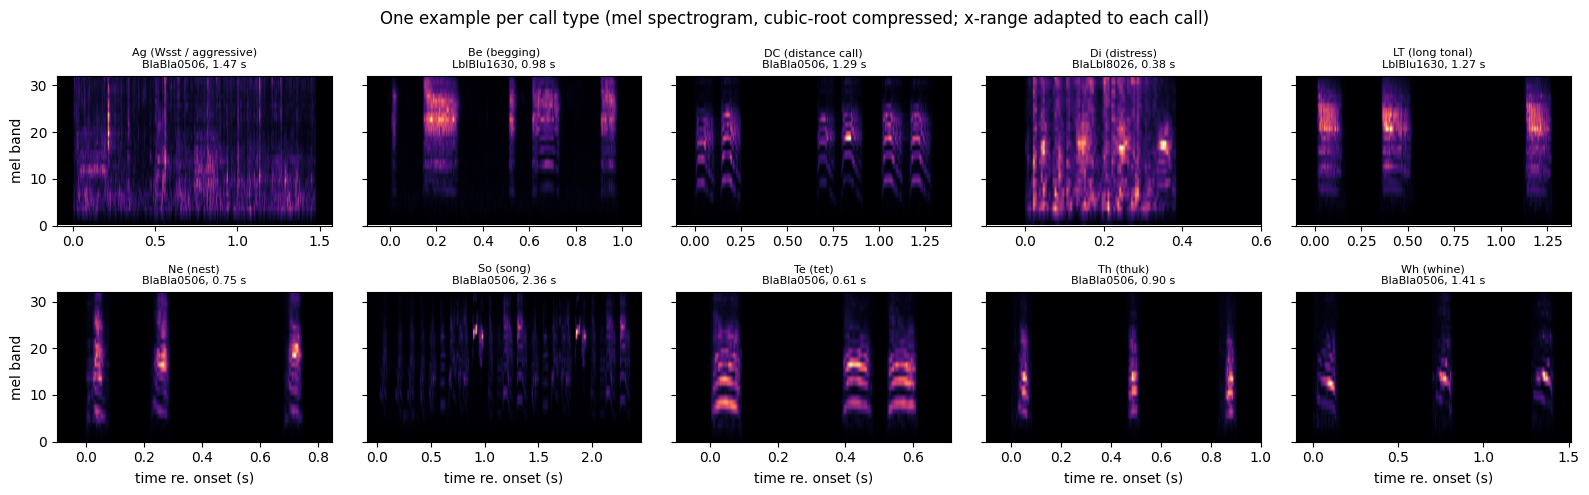

In [5]:
t = (np.arange(ds.T) - ds.onset_bin) * ds.dt / 1000       # seconds re. onset
fig, axes = plt.subplots(2, 5, figsize=(16, 5), sharey=True)
for ax, ct in zip(axes.flat, sorted(CALL_TYPES)):
    s = next(s for s in calls if ds.stim_meta[s]['call_type'] == ct)
    sm = ds.stim_meta[s]
    ax.imshow(ds.stims[s][0].numpy(), origin='lower', aspect='auto', cmap='magma',
              extent=[t[0], t[-1], 0, ds.F])
    ax.set_xlim(-0.1, max(0.6, sm['sound_offset_s'] + 0.1))
    ax.set_title(f"{ct} ({CALL_TYPES[ct]})\n{sm['vocalizer']}, {sm['duration_s']:.2f} s", fontsize=8)
for ax in axes[1]:
    ax.set_xlabel('time re. onset (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('mel band')
fig.suptitle('One example per call type (mel spectrogram, cubic-root compressed; x-range adapted to each call)')
fig.tight_layout()

Each panel is one stimulus as the loader serves it: a 32-band mel
spectrogram over time relative to the logged onset. Most call stimuli are
short sequences of two or three calls of the same type from one vocalizer,
separated by silence. The call types differ in spectral structure (e.g. the
harmonic stacks of tets, Te, vs. the broadband noise of Wsst calls, Ag) and in
duration. Song motifs (So) are the longest.

## 3. One unit: spectrogram, raster and PSTH

Pick a unit that is a candidate single unit (`spike_snr > 5`, the paper's
cut), responds clearly at onset (high `auditory_z`), and has at least
6 trials for 4 different call types.

In [6]:
def enough(s, n, k=6):
    return bool(m[s, n]) and ds.responses[s][n].shape[0] >= k

cands = [(ds.nrn_meta[n]['auditory_z'], n) for n in range(ds.N_neurons)
         if (ds.nrn_meta[n]['spike_snr'] or 0) > 5]
for z, n_idx in sorted(cands, reverse=True):
    picks = {}
    for s in calls:
        ct = ds.stim_meta[s]['call_type']
        if ct not in picks and enough(s, n_idx):
            picks[ct] = s
    if len(picks) >= 4:
        break
picks = dict(list(picks.items())[:4])
nm = ds.nrn_meta[n_idx]
print({k: nm[k] for k in ('cell_id', 'site', 'depth_um', 'spike_snr', 'auditory_z', 'n_trials')})

{'cell_id': 'ZF4F_2t_190612_134337_e16-c98', 'site': 'ZF4F_2t_190612_134337', 'depth_um': 500.0, 'spike_snr': 9.173217455901456, 'auditory_z': 1.3020862852113038, 'n_trials': 697}


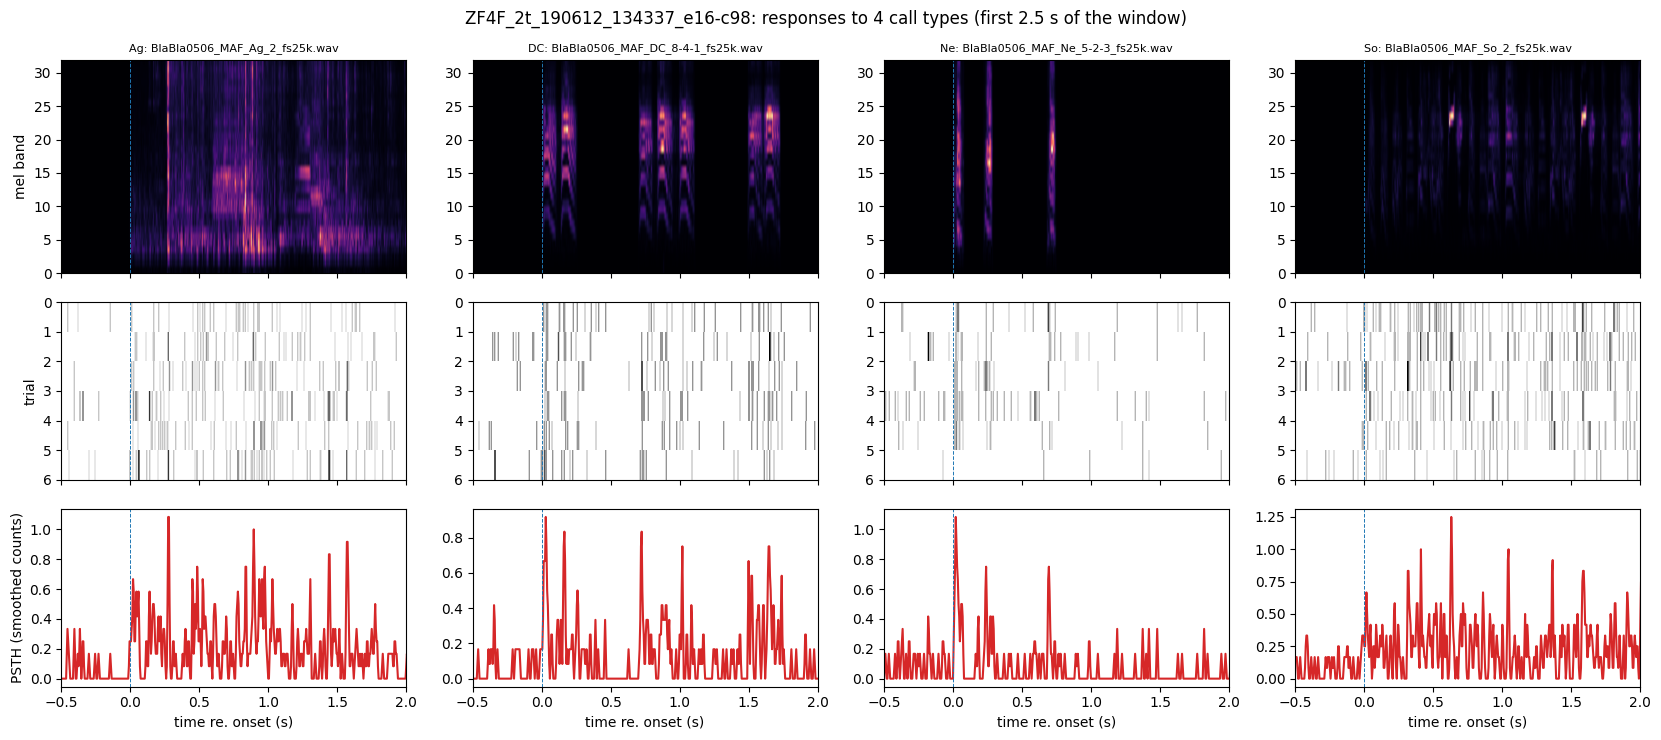

In [7]:
fig, axes = plt.subplots(3, len(picks), figsize=(4.2 * len(picks), 7.5), sharex=True,
                         gridspec_kw={'height_ratios': [1.2, 1, 1]})
for j, (ct, s) in enumerate(picks.items()):
    resp = ds.responses[s][n_idx].numpy()
    axes[0, j].imshow(ds.stims[s][0].numpy(), origin='lower', aspect='auto', cmap='magma',
                      extent=[t[0], t[-1], 0, ds.F])
    axes[0, j].set_title(f"{ct}: {ds.stim_meta[s]['name']}", fontsize=8)
    axes[1, j].imshow(resp, aspect='auto', cmap='Greys', interpolation='nearest',
                      extent=[t[0], t[-1], resp.shape[0], 0])
    axes[2, j].plot(t, resp.mean(0), color='C3')
    for ax in axes[:, j]:
        ax.axvline(0, color='C0', lw=0.7, ls='--')
    axes[2, j].set_xlabel('time re. onset (s)')
    axes[0, j].set_xlim(-0.5, 2.0)
axes[0, 0].set_ylabel('mel band'); axes[1, 0].set_ylabel('trial'); axes[2, 0].set_ylabel('PSTH (smoothed counts)')
fig.suptitle(f"{nm['cell_id']}: responses to 4 call types (first 2.5 s of the window)")
fig.tight_layout()

Top: the stimulus. Middle: one row per kept trial (smoothed spike counts).
Bottom: the trial average. The dashed line marks the logged onset. The
window continues to +4.5 s, but here it is cut at 2 s, where these calls
have long ended.

## 4. Population check: do stimuli and spikes line up?

Average the PSTH over every valid (call, unit) pair, each normalised by its
own mean rate, and compare it with the average stimulus energy. If the
loader aligns the two correctly, the population should be flat before the
logged onset and respond within a few tens of ms after it.

peak population rate 3.25x its mean, at 30 ms


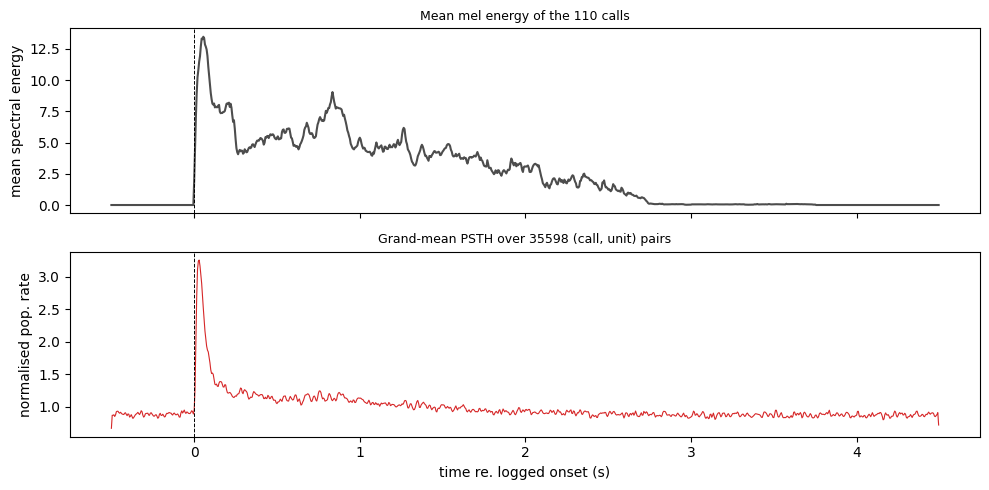

In [8]:
psth = np.zeros(ds.T); npairs = 0
for s in calls:
    for n in range(ds.N_neurons):
        if m[s, n]:
            r = ds.responses[s][n].numpy().mean(0)
            psth += r / (r.mean() + 1e-9); npairs += 1
psth /= npairs
energy = np.mean([ds.stims[s][0].sum(0).numpy() for s in calls], 0)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, energy, color='0.3'); axes[0].set_ylabel('mean spectral energy')
axes[0].set_title(f'Mean mel energy of the {len(calls)} calls', fontsize=9)
axes[1].plot(t, psth, color='C3', lw=0.8); axes[1].set_ylabel('normalised pop. rate')
axes[1].set_title(f'Grand-mean PSTH over {npairs} (call, unit) pairs', fontsize=9)
axes[1].set_xlabel('time re. logged onset (s)')
for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=0.7)
fig.tight_layout()
print(f'peak population rate {psth.max():.2f}x its mean, at {t[psth.argmax()] * 1000:.0f} ms')

The population is flat during the 0.5 s of pre-stimulus silence, jumps
sharply right after the logged onset, and then decays with the mean sound
energy. Stimulus and responses are aligned.

## 5. Unit quality metadata

The release includes every sorted unit. Two per-unit numbers help select them:

- `spike_snr`: the authors' spike-waveform SNR, a measure of spike-sorting
  quality. The paper keeps units with SNR > 5 as candidate single units.
- `auditory_z`: the effect size of the firing-rate change 0–500 ms after
  vs. 500–0 ms before onset, over all the unit's trials. It is the quantity
  behind the paper's "auditory" test; negative values mean the unit is
  inhibited by sound.

`ds.compute_neuron_quality()` adds the response-based `snr` and `ccmax`
too (about 3 min on everything).

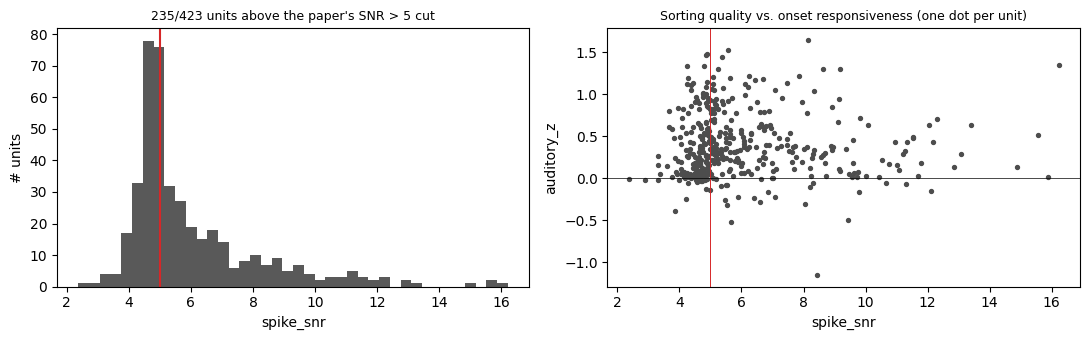

In [9]:
snr = np.array([n['spike_snr'] for n in ds.nrn_meta], float)
az = np.array([n['auditory_z'] for n in ds.nrn_meta], float)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(snr, bins=40, color='0.35'); axes[0].axvline(5, color='C3')
axes[0].set_xlabel('spike_snr'); axes[0].set_ylabel('# units')
axes[0].set_title(f'{(snr > 5).sum()}/{len(snr)} units above the paper\'s SNR > 5 cut', fontsize=9)
axes[1].scatter(snr, az, s=8, color='0.3'); axes[1].axvline(5, color='C3', lw=0.7); axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('spike_snr'); axes[1].set_ylabel('auditory_z')
axes[1].set_title('Sorting quality vs. onset responsiveness (one dot per unit)', fontsize=9)
fig.tight_layout()

## 6. Trial quality bookkeeping

When the cache is built, each playback's cage-microphone recording is compared
with the stimulus to find where the sound really was. By default, the loader
drops playbacks where the sound was confidently more than 25 ms away from the
logged onset, and playbacks whose window already contains the next playback.
`ds.playback_meta[site]` keeps every playback with those measurements.

playbacks: 24707   misaligned: 181   overlapping the next one: 521   dropped: 695


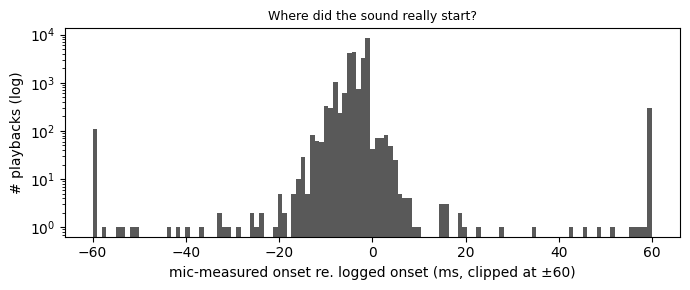

In [10]:
pm = [p for v in ds.playback_meta.values() for p in v]
print(f"playbacks: {len(pm)}   misaligned: {sum(p['misaligned'] for p in pm)}   "
      f"overlapping the next one: {sum(p['next_playback_overlap'] for p in pm)}   "
      f"dropped: {sum(p['dropped'] for p in pm)}")
off = np.array([p['mic_offset_ms'] for p in pm if 'mic_offset_ms' in p])
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.clip(off, -60, 60), bins=121, color='0.35', log=True)
ax.set_xlabel('mic-measured onset re. logged onset (ms, clipped at ±60)'); ax.set_ylabel('# playbacks (log)')
ax.set_title('Where did the sound really start?', fontsize=9)
fig.tight_layout()

Almost all playbacks start within a few ms of the logged onset. The bars at
±60 ms collect the rare large offsets (up to seconds), including playbacks the
microphone could not locate confidently. Only confident ones are flagged
`misaligned`.

## 7. Simultaneous recordings, trial by trial

All units at a site were recorded at the same time. `ds.trial_ids[s][n]`
gives the site-wide playback index of each response row, so the
population's response to **one single playback** can be put back together.

site ZF4F_6t_190616_142033: 27 units; stim BlaBla0506_MAF_Ag_2_fs25k.wav; playback 1043 held by 12 units


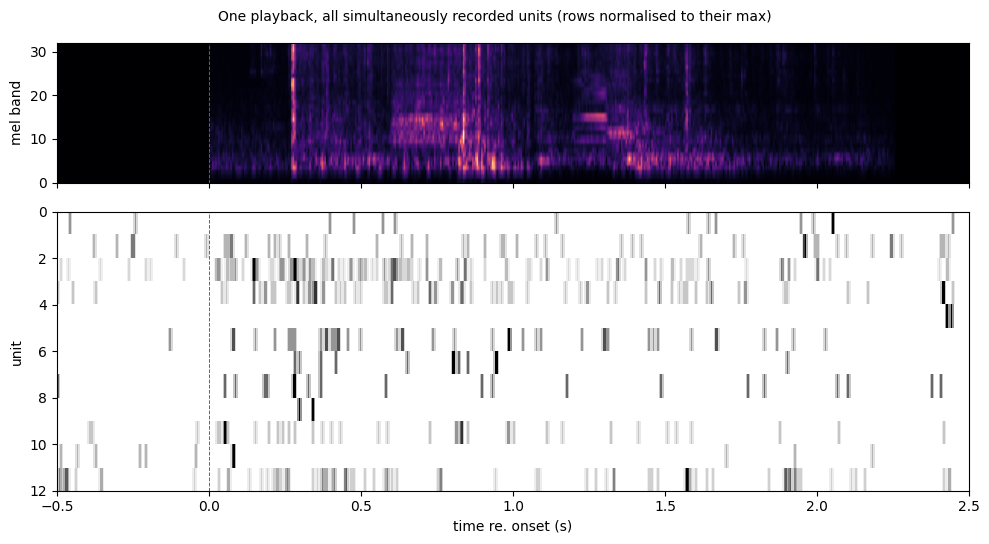

In [11]:
site = max(ds.sites, key=lambda st: sum(n['site'] == st for n in ds.nrn_meta))
units = [n for n in range(ds.N_neurons) if ds.nrn_meta[n]['site'] == site]
s = max(calls, key=lambda s: sum(bool(m[s, n]) for n in units))
common = set.intersection(*[set(ds.trial_ids[s][n]) for n in units if m[s, n]])
trial = sorted(common)[0] if common else ds.trial_ids[s][next(n for n in units if m[s, n])][0]
rows = [(n, ds.responses[s][n][ds.trial_ids[s][n].index(trial)].numpy())
        for n in units if m[s, n] and trial in ds.trial_ids[s][n]]
print(f'site {site}: {len(units)} units; stim {ds.stim_meta[s]["name"]}; playback {trial} held by {len(rows)} units')

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True, gridspec_kw={'height_ratios': [1, 2]})
axes[0].imshow(ds.stims[s][0].numpy(), origin='lower', aspect='auto', cmap='magma', extent=[t[0], t[-1], 0, ds.F])
axes[0].set_ylabel('mel band')
mat = np.stack([r for _, r in rows]); mat = mat / (mat.max(1, keepdims=True) + 1e-9)
axes[1].imshow(mat, aspect='auto', cmap='Greys', interpolation='nearest', extent=[t[0], t[-1], len(rows), 0])
axes[1].set_ylabel('unit'); axes[1].set_xlabel('time re. onset (s)')
for ax in axes:
    ax.axvline(0, color='C0', ls='--', lw=0.7)
axes[0].set_xlim(-0.5, 2.5)
fig.suptitle(f'One playback, all simultaneously recorded units (rows normalised to their max)', fontsize=10)
fig.tight_layout()

## 8. Filtering

The full deepSTRF selection API applies. For example, keep only distance
calls and candidate single units that respond at onset:

In [12]:
ds.reset_stim_selection(); ds.reset_pop_selection()
ds.select_call_type('DC')
ds.select_pop_by_nrn_predicate(lambda n: (n['spike_snr'] or 0) > 5 and n['auditory_z'] > 0.3)
print(f'{len(ds)} distance calls x {ds.n_selected} units that heard them')
batch = ds[0]
print({k: (tuple(v.shape) if torch.is_tensor(v) else type(v).__name__) for k, v in batch.items()})

14 distance calls x 119 units that heard them
{'stims': (1, 32, 1000), 'responses': 'list', 'valid_mask': (119,), 'stim_meta': 'dict'}
